# Predicting Aqueous Solubility

### 1. Import Libraries

In [333]:
import pandas as pd
import numpy as np

In [334]:
!pip install scikit-learn
!pip install py3dmol

### 2. Load Delaney Solubility Dataset- 
Predicting aqueous solubility (logS)

In [335]:
url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)

### 3. Chemical Data Cleaning

In [362]:
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Cleans molecular dataset by: 
# removing salts, keeping largest fragment, canonicalizing SMILES, & filtering molecule size.

def clean_chemical_data(df, smiles_col, target_col):
    remover = SaltRemover()
    cleaned_rows = []
    
    for index, row in df.iterrows():
        smiles = row[smiles_col]
        mol = Chem.MolFromSmiles(smiles)
        
        if mol:
            mol = remover.StripMol(mol)
            
            frags = Chem.GetMolFrags(mol, asMols=True)
            if frags:
                main_mol = max(frags, default=mol, key=lambda m: m.GetNumAtoms())
                
                clean_smiles = Chem.MolToSmiles(main_mol, isomericSmiles=True)
                
                if 5 < main_mol.GetNumAtoms() < 100:
                    cleaned_rows.append({
                        'smiles': clean_smiles,
                        'target': row[target_col]
                    })
                    
    new_df = pd.DataFrame(cleaned_rows)
    new_df = new_df.groupby('smiles')['target'].mean().reset_index()
    
    return new_df

df_final = clean_chemical_data(df, 'smiles', 'measured log solubility in mols per litre')
print(f"Dataset went from {len(df)} to {len(df_final)} high-quality samples.")

Dataset went from 1128 to 1011 high-quality samples.


In [337]:
print(df[['Compound ID', 'smiles', 'measured log solubility in mols per litre']].head())

  Compound ID                                             smiles  \
0   Amigdalin  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...   
1    Fenfuram                             Cc1occc1C(=O)Nc2ccccc2   
2      citral                               CC(C)=CCCC(C)=CC(=O)   
3      Picene                 c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43   
4   Thiophene                                            c1ccsc1   

   measured log solubility in mols per litre  
0                                      -0.77  
1                                      -3.30  
2                                      -2.06  
3                                      -7.87  
4                                      -1.33  


In [338]:
from rdkit import Chem
from rdkit.Chem import Descriptors

### 4. Model 1: Physicochemical Descriptor Model Features:
- Molecular Weight
- LogP
- Hydrogen Bond Donors 
- Hydrogen Bond Acceptors
- Rotatable Bonds

In [339]:
# Generate classical physicochemical descriptors
def get_physchem_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return {
            'MW': Descriptors.MolWt(mol),
            'LogP': Descriptors.MolLogP(mol),
            'H_Donors': Descriptors.NumHDonors(mol),
            'H_Acceptors': Descriptors.NumHAcceptors(mol),
            'Rotatable_Bonds': Descriptors.NumRotatableBonds(mol)
        }
    return None

In [340]:
features_list = df_final['smiles'].apply(get_physchem_features)

features_df = pd.DataFrame(list(features_list))
valid_idx = features_df.dropna().index 

X = features_df.loc[valid_idx]
y = df_final.loc[valid_idx, 'target']

### 5. Train Random Forest Regression Model

In [341]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [342]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [343]:
descriptor_model = RandomForestRegressor(n_estimators=200, max_depth=10)
descriptor_model.fit(X_train, y_train)

preds_desc = descriptor_model.predict(X_test)

print(f"Descriptor Model R²: {r2_score(y_test, preds_desc):.3f}")

Descriptor Model R²: 0.842


### 6. Error Analysis 
- Identify molecules with highest prediction error

In [344]:
results = pd.DataFrame({
    'SMILES': df_final.loc[y_test.index, 'smiles'],
    'Actual': y_test,
    'Predicted': preds_desc
})

In [345]:
results['Residual'] = results['Actual'] - results['Predicted']
results['Abs_Error'] = results['Residual'].abs()

In [346]:
outliers = results.sort_values(by='Abs_Error', ascending=False).head(5)

In [347]:
print("Top 5 Model Outliers:")
print(outliers)

Top 5 Model Outliers:
                         SMILES  Actual  Predicted  Residual  Abs_Error
497  CNC(=O)C(C)SCCSP(=O)(OC)OC   1.144  -2.916771  4.060771   4.060771
590    Cc1cc(=O)n(-c2ccccc2)n1C   0.715  -2.465631  3.180631   3.180631
436            CCOP(=O)(OCC)OCC   0.430  -2.489667  2.919667   2.919667
532          COP(=O)(NC(C)=O)SC   0.540  -2.061280  2.601280   2.601280
500   CNC(=O)ON=C(SC)C(=O)N(C)C   0.106  -2.421773  2.527773   2.527773


In [348]:
results['Abs_Error'] = results['Residual'].abs()
outliers = results.sort_values(by='Abs_Error', ascending=False).head(5)

In [349]:
outliers

,SMILES,Actual,Predicted,Residual,Abs_Error
497,CNC(=O)C(C)SCCSP(=O)(OC)OC,1.144,-2.916771,4.060771,4.060771
590,Cc1cc(=O)n(-c2ccccc2)n1C,0.715,-2.465631,3.180631,3.180631
436,CCOP(=O)(OCC)OCC,0.430,-2.489667,2.919667,2.919667
532,COP(=O)(NC(C)=O)SC,0.540,-2.061280,2.601280,2.601280
500,CNC(=O)ON=C(SC)C(=O)N(C)C,0.106,-2.421773,2.527773,2.527773


### 3D Molecular Visualization 
- visualizes the top outlier molecules in 3D

In [350]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

def draw_3d_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol) 
    
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    AllChem.MMFFOptimizeMolecule(mol) 
    
    mblock = Chem.MolToMolBlock(mol)
    
    view = py3Dmol.view(width=800, height=400)
    view.addModel(mblock, 'sdf')
    view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}}) # Atoms as spheres, bonds as sticks
    view.zoomTo()
    return view.show()


top_outlier_smiles = outliers.iloc[0]['SMILES']
draw_3d_molecule(top_outlier_smiles)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 8. Model 2: Morgan Fingerprint Model 
- Circular fingerprints capturing molecular substructures

In [351]:
from rdkit.Chem import AllChem

def get_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        return np.array(fp)
    return None


### 9. Train Fingerprint-Based Random Forest

In [363]:
fingerprints = df_final['smiles'].apply(get_morgan_fp)

valid_idx = fingerprints.dropna().index

X = np.array(list(fingerprints.loc[valid_idx]))
y = df_final.loc[valid_idx, 'target']


In [353]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X, y, test_size=0.2, random_state=42)
fingerprint_model = RandomForestRegressor(n_estimators=200, max_depth=None,min_samples_leaf=2,random_state=42)
fingerprint_model.fit(X_train_f, y_train_f)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [354]:
preds = fingerprint_model.predict(X_test_f)
print(f"R-squared: {r2_score(y_test_f, preds):.3f}")

R-squared: 0.629


In [355]:
results = pd.DataFrame({
    'SMILES': df_final.loc[y_test_f.index, 'smiles'],
    'Actual': y_test_f,
    'Predicted': preds
})

In [358]:
results = pd.DataFrame({
    'SMILES': df_final.loc[y_test_f.index, 'smiles'],
    'Actual': y_test_f,
    'Predicted': preds
})

results['Residual'] = results['Actual'] - results['Predicted']
results['Abs_Error'] = results['Residual'].abs()

outliers = results.sort_values(by='Abs_Error', ascending=False).head(5)
outliers


,SMILES,Actual,Predicted,Residual,Abs_Error
590,Cc1cc(=O)n(-c2ccccc2)n1C,0.715,-3.488168,4.203168,4.203168
523,COC(C)(C)CCCC(C)CC=CC(C)=CC(=O)OC(C)C,-5.190,-1.273751,-3.916249,3.916249
327,CCCCCCCCCCCCCCCCCCO,-8.400,-4.564778,-3.835222,3.835222
497,CNC(=O)C(C)SCCSP(=O)(OC)OC,1.144,-2.689813,3.833813,3.833813
500,CNC(=O)ON=C(SC)C(=O)N(C)C,0.106,-3.096754,3.202754,3.202754


In [359]:
top_outlier_smiles = outliers.iloc[0]['SMILES']
draw_3d_molecule(top_outlier_smiles)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### 10. Feature Importance Visualization

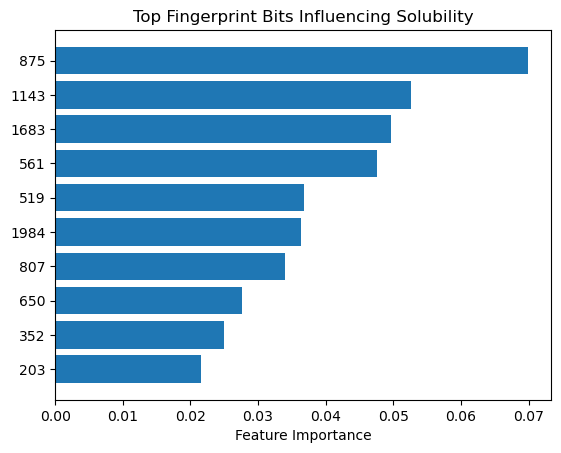

In [360]:
import matplotlib.pyplot as plt

importances = fingerprint_model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 bits

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top Fingerprint Bits Influencing Solubility")
plt.xlabel("Feature Importance")
plt.show()


In [361]:
print("Pipeline Complete")
print("Total molecules analyzed:", len(df_final))


Pipeline Complete
Total molecules analyzed: 1011
